# **Data analysis on users**

This notebook runs a bunch of data analysis on the users and saves the analysis to `data/processed/users`.

In [38]:
import sys
import subprocess


subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade",
    "pandas",
    "plotly",
    "wordcloud",
    "matplotlib",
    "numpy",
    "kaleido",
    "pyarrow"
])

0

# Imports and setup

In [39]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.pyplot as plt  
from pathlib import Path
import json
import plotly.io as pio

df = pd.read_parquet('../data/users.parquet')
index = {
    "numerical":{},
    "top":{},
    "graphs":{},
}

In [40]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()

Dataset shape: (13360, 16)

Columns: ['id', 'slack_id', 'display_name', 'bio', 'projects_count', 'devlogs_count', 'votes_count', 'ships_count', 'coding_time_seconds', 'coding_time_seconds_today', 'balance', 'created_at', 'updated_at', 'avatar', 'custom_css', 'scraped_at']

Data types:
id                                         int64
slack_id                                  object
display_name                              object
bio                                       object
projects_count                             int64
devlogs_count                              int64
votes_count                                int64
ships_count                                int64
coding_time_seconds                        int64
coding_time_seconds_today                  int64
balance                                    Int64
created_at                   datetime64[ns, UTC]
updated_at                   datetime64[ns, UTC]
avatar                                    object
custom_css                  

,id,slack_id,display_name,bio,projects_count,devlogs_count,votes_count,ships_count,coding_time_seconds,coding_time_seconds_today,balance,created_at,updated_at,avatar,custom_css,scraped_at
0,1,U03DFNYGPCN,Malted,None,1,1,12,1,133510,6540,0,2025-06-15 16:27:55.496000+00:00,2025-08-10 00:54:37.885000+00:00,https://avatars.slack-edge.com/2025-04-02/8691...,None,2025-08-15 04:02:43.390000+00:00
1,2,U080A3QP42C,Rowan,we ball hard,2,0,2,0,594227,1479,3,2025-06-15 16:30:11.969000+00:00,2025-08-10 02:48:09.410000+00:00,https://avatars.slack-edge.com/2025-06-28/9118...,None,2025-08-15 04:02:43.390000+00:00
2,3,U06QK6AG3RD,nora,i'm like if a girl was working on Summer of Ma...,2,3,2,2,335751,144,385,2025-06-15 16:54:28.478000+00:00,2025-08-06 19:48:37.175000+00:00,https://avatars.slack-edge.com/2024-10-26/7934...,"body { filter: invert(1); font-family: ""Papyrus""}",2025-08-15 04:02:43.390000+00:00
3,4,U05F4B48GBF,cskartikey,uhhhh?,3,5,42,0,273641,120,239,2025-06-15 17:35:55.246000+00:00,2025-07-09 15:02:58.138000+00:00,https://avatars.slack-edge.com/2025-05-17/8913...,body {\n display: none;\n}\n,2025-08-15 04:02:43.390000+00:00
4,5,U07L45W79E1,Neon,Meow meow - https://saahild.com,11,27,43,6,647605,5673,365,2025-06-15 18:46:29.520000+00:00,2025-08-13 04:52:22.561000+00:00,https://avatars.slack-edge.com/2025-04-22/8794...,"body::after {\r\n content: """";\r\n position:...",2025-08-15 04:02:43.390000+00:00


In [41]:
EXPORT_DIR = Path('../data/processed/users').resolve()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_WIDTH = 1100
DEFAULT_HEIGHT = 420

som_wide = go.layout.Template(layout=dict(
    width=DEFAULT_WIDTH,
    margin=dict(l=60, r=30, t=60, b=50),
))
pio.templates['som_wide'] = som_wide
pio.templates.default = 'plotly_white+som_wide'

try:
    pio.renderers.default = 'vscode'
except Exception:
    pass


def register_graph(key: str,name:str, description: str, image_file: str):
    index['graphs'][key] = {
        'name': name,
        'description': description,
        'image_file': Path(image_file).name
    }

def save_plotly(fig, name: str, description: str, scale: int = 2, width=None, height=None, friendly_name: str = ""):
    filename = f"{name}.png"
    out_path = EXPORT_DIR / filename
    try:
        exp_width = width if width is not None else (fig.layout.width or DEFAULT_WIDTH)
        exp_height = height if height is not None else (fig.layout.height or DEFAULT_HEIGHT)
        fig.write_image(str(out_path), scale=scale, width=exp_width,
                        height=exp_height)
        register_graph(name,friendly_name, description, filename)
    except Exception as e:
        print(f'Failed to save Plotly figure {name}: {e}')


def save_matplotlib_current(name: str, description: str, dpi: int = 150, friendly_name: str = ""):
    filename = f"{name}.png"
    out_path = EXPORT_DIR / filename
    try:
        plt.gcf().savefig(out_path, bbox_inches='tight', dpi=dpi, facecolor='white')
        register_graph(name, friendly_name, description, filename)
    except Exception as e:
        print(f'Failed to save Matplotlib figure {name}: {e}')

def save_to_index(key: str,name:str,description:str, data, type="numerical"):
    if isinstance(data, pd.DataFrame):
        records = data.to_dict(orient='records')
        indexed = {i: rec for i, rec in enumerate(records)}
        index[type][key] = {
            'name': name,
            'description': description,
            'data': indexed,
        }
    else:
        index[type][key] = {
            'name': name,
            'description': description,
            'data': data
        }

# **Numerical data**
Shows some numerical data

### Average projects per user

Compute and display the average of `projects_count`.

In [42]:
avg_projects = pd.to_numeric(df['projects_count'], errors='coerce').mean()
print(f"Average projects per user: {avg_projects:.2f}")

save_to_index('avg_projects', name='Average projects per user', description='The average number of projects per user.', data=float(avg_projects), type='numerical')

Average projects per user: 0.50


### Average devlogs per user

Compute and display the average of `devlogs_count`.

In [43]:
avg_devlogs = pd.to_numeric(df['devlogs_count'], errors='coerce').mean()
print(f"Average devlogs per user: {avg_devlogs:.2f}")

save_to_index('avg_devlogs', name='Average devlogs per user', description='The average number of devlogs per user.', data=float(avg_devlogs), type='numerical')

Average devlogs per user: 2.13


### Average coding time per user (hours)

Compute and display the average of `coding_time_seconds` converted to hours.

In [44]:
avg_coding_hours = pd.to_numeric(df['coding_time_seconds'], errors='coerce').mean() / 3600
print(f"Average coding time per user: {avg_coding_hours:.2f} hours")

save_to_index('avg_coding_hours', name='Average coding time per user', description='The average coding time per user in hours.', data=float(avg_coding_hours), type='numerical')

Average coding time per user: 15.44 hours


### Average balance per user

Compute and display the average of `balance`.

In [45]:
avg_balance = pd.to_numeric(df['balance'], errors='coerce').mean()
print(f"Average balance per user: {avg_balance:.2f}")

save_to_index('avg_balance', name='Average balance per user', description='The average balance per user.', data=float(avg_balance), type='numerical')

Average balance per user: 24.14


### Average votes per user

Compute and display the average of `votes_count`.

In [46]:
avg_votes = pd.to_numeric(df['votes_count'], errors='coerce').mean()
print(f"Average votes per user: {avg_votes:.2f}")

save_to_index('avg_votes', name='Average votes per user', description='The average number of votes per user.', data=float(avg_votes), type='numerical')

Average votes per user: 4.88


### Average ships per user

Compute and display the average of `ships_count`.

In [47]:
avg_ships = pd.to_numeric(df['ships_count'], errors='coerce').mean()
print(f"Average ships per user: {avg_ships:.2f}")

save_to_index('avg_ships', name='Average ships per user', description='The average number of ships per user.', data=float(avg_ships), type='numerical')

Average ships per user: 0.21


### Inactive users analysis

Count users with zero activity across different metrics to identify inactive accounts.

In [ ]:
_df = df.copy()

for col in ['balance', 'coding_time_seconds', 'ships_count', 'projects_count', 'devlogs_count', 'votes_count']:
    _df[f'{col}_num'] = pd.to_numeric(_df[col], errors='coerce').fillna(0)

inactive_stats = {
    'zero_balance': (_df['balance_num'] == 0).sum(),
    'zero_coding_time': (_df['coding_time_seconds_num'] == 0).sum(),
    'zero_ships': (_df['ships_count_num'] == 0).sum(),
    'zero_projects': (_df['projects_count_num'] == 0).sum(),
    'zero_devlogs': (_df['devlogs_count_num'] == 0).sum(),
    'zero_votes': (_df['votes_count_num'] == 0).sum()
}

completely_inactive = _df[
    (_df['balance_num'] == 0) & 
    (_df['coding_time_seconds_num'] == 0) & 
    (_df['ships_count_num'] == 0) & 
    (_df['projects_count_num'] == 0) & 
    (_df['devlogs_count_num'] == 0) & 
    (_df['votes_count_num'] == 0)
].shape[0]

inactive_stats['completely_inactive'] = completely_inactive
total_users = len(_df)

print("Inactive Users Analysis:")
print(f"Total users: {total_users}")
print(f"Users with zero balance: {inactive_stats['zero_balance']} ({inactive_stats['zero_balance']/total_users*100:.1f}%)")
print(f"Users with zero coding time: {inactive_stats['zero_coding_time']} ({inactive_stats['zero_coding_time']/total_users*100:.1f}%)")
print(f"Users with zero ships: {inactive_stats['zero_ships']} ({inactive_stats['zero_ships']/total_users*100:.1f}%)")
print(f"Users with zero projects: {inactive_stats['zero_projects']} ({inactive_stats['zero_projects']/total_users*100:.1f}%)")
print(f"Users with zero devlogs: {inactive_stats['zero_devlogs']} ({inactive_stats['zero_devlogs']/total_users*100:.1f}%)")
print(f"Users with zero votes: {inactive_stats['zero_votes']} ({inactive_stats['zero_votes']/total_users*100:.1f}%)")
print(f"Completely inactive users (all zeros): {completely_inactive} ({completely_inactive/total_users*100:.1f}%)")

inactive_with_percentages = {}
for key, value in inactive_stats.items():
    inactive_with_percentages[key] = {
        'count': int(value),
        'percentage': round(value/total_users*100, 1)
    }
inactive_with_percentages['total_users'] = int(total_users)

save_to_index('inactive_users', name='Inactive users analysis', description='Count and percentage of users with zero activity across different metrics.', data=inactive_with_percentages, type='numerical')

Inactive Users Analysis:
Total users: 13360
Users with zero balance: 12304 (92.1%)
Users with zero coding time: 7186 (53.8%)
Users with zero ships: 11992 (89.8%)
Users with zero projects: 10313 (77.2%)
Users with zero devlogs: 10826 (81.0%)
Users with zero votes: 11429 (85.5%)
Completely inactive users (all zeros): 7160 (53.6%)


### Custom CSS usage

Analyze how many users have custom CSS.

In [ ]:
custom_css_not_null = df['custom_css'].notna() & (df['custom_css'].astype(str).str.strip() != '') & (df['custom_css'].astype(str) != 'nan')
users_with_css = custom_css_not_null.sum()
total_users = len(df)
css_percentage = (users_with_css / total_users) * 100

print(f"Users with custom CSS: {users_with_css} out of {total_users} ({css_percentage:.1f}%)")
print(f"Users without custom CSS: {total_users - users_with_css} ({100 - css_percentage:.1f}%)")

css_stats = {
    'users_with_css': int(users_with_css),
    'users_without_css': int(total_users - users_with_css),
    'percentage_with_css': round(css_percentage, 1),
    'percentage_without_css': round(100 - css_percentage, 1),
    'total_users': int(total_users)
}

save_to_index('custom_css_usage', name='Custom CSS usage', description='Analysis of how many users have custom CSS.', data=css_stats, type='numerical')

Users with custom CSS: 32 out of 13360 (0.2%)
Users without custom CSS: 13328 (99.8%)


# **Top stuff**

Shows the top stuff

### Top 3 users by projects count

Show the top 3 users sorted by projects count

In [71]:
_df = df.copy()
_df['projects_count_num'] = pd.to_numeric(_df['projects_count'], errors='coerce')
_df['display_name_clean'] = _df['display_name'].astype('object').fillna('(unnamed)').astype(str)

top3 = (_df[['id', 'display_name_clean', 'projects_count_num']]
        .dropna()
        .nlargest(3, 'projects_count_num')
        .copy())

top3['projects_count_num'] = top3['projects_count_num'].astype(int)
top3['profile_link'] = top3['id'].apply(
    lambda x: f"https://summer.hackclub.com/users/{x}")
top3.reset_index(drop=True, inplace=True)

print("Top 3 users by projects count:")


save_to_index('top_users_projects', name='Top 3 users by projects count',
              description='The top 3 users by number of projects.', data=top3, type='top')
top3

Top 3 users by projects count:


,id,display_name_clean,projects_count_num,profile_link
0,1297,YASH PANCHAL,19,https://summer.hackclub.com/users/1297
1,9550,Suhail,19,https://summer.hackclub.com/users/9550
2,5284,arn,16,https://summer.hackclub.com/users/5284


### Top 3 users by coding time

Show the top 3 users sorted by coding time (hours)

In [72]:
_df = df.copy()
_df['coding_time_hours'] = pd.to_numeric(_df['coding_time_seconds'], errors='coerce') / 3600
_df['display_name_clean'] = _df['display_name'].astype('object').fillna('(unnamed)').astype(str)

top3 = (_df[['id', 'display_name_clean', 'coding_time_hours']]
        .dropna()
        .nlargest(3, 'coding_time_hours')
        .copy())

top3['coding_time_hours'] = top3['coding_time_hours'].round(2)
top3['profile_link'] = top3['id'].apply(
    lambda x: f"https://summer.hackclub.com/users/{x}")
top3.reset_index(drop=True, inplace=True)

print("Top 3 users by coding time (hours):")

save_to_index('top_users_coding_time', name='Top 3 users by coding time',
              description='The top 3 users by coding time (in hours).', data=top3, type='top')
top3

Top 3 users by coding time (hours):


,id,display_name_clean,coding_time_hours,profile_link
0,11921,Shivam Gupta,1537.10,https://summer.hackclub.com/users/11921
1,4693,Trou,548.31,https://summer.hackclub.com/users/4693
2,11680,Yahya Khan,532.45,https://summer.hackclub.com/users/11680


### Top 3 users by balance

Show the top 3 users sorted by balance

In [73]:
_df = df.copy()
_df['balance_num'] = pd.to_numeric(_df['balance'], errors='coerce')
_df['display_name_clean'] = _df['display_name'].astype('object').fillna('(unnamed)').astype(str)

top3 = (_df[['id', 'display_name_clean', 'balance_num']]
        .dropna()
        .nlargest(3, 'balance_num')
        .copy())

top3['balance_num'] = top3['balance_num'].astype(int)
top3['profile_link'] = top3['id'].apply(
    lambda x: f"https://summer.hackclub.com/users/{x}")
top3.reset_index(drop=True, inplace=True)

print("Top 3 users by balance:")


save_to_index('top_users_balance', name='Top 3 users by balance',
              description='The top 3 users by balance.', data=top3, type='top')
top3

Top 3 users by balance:


,id,display_name_clean,balance_num,profile_link
0,112,Checkers,3661,https://summer.hackclub.com/users/112
1,11144,190 votes to go,3634,https://summer.hackclub.com/users/11144
2,1517,Kevin,3497,https://summer.hackclub.com/users/1517


### Top 3 users by votes

Show the top 3 users sorted by votes count

In [75]:
_df = df.copy()
_df['votes_count_num'] = pd.to_numeric(_df['votes_count'], errors='coerce')
_df['display_name_clean'] = _df['display_name'].astype('object').fillna('(unnamed)').astype(str)

top3 = (_df[['id', 'display_name_clean', 'votes_count_num']]
        .dropna()
        .nlargest(3, 'votes_count_num')
        .copy())

top3['votes_count_num'] = top3['votes_count_num'].astype(int)
top3['profile_link'] = top3['id'].apply(
    lambda x: f"https://summer.hackclub.com/users/{x}")
top3.reset_index(drop=True, inplace=True)

print("Top 3 users by votes:")

save_to_index('top_users_votes', name='Top 3 users by votes',
              description='The top 3 users by number of votes.', data=top3, type='top')
top3

Top 3 users by votes:


,id,display_name_clean,votes_count_num,profile_link
0,3446,Saketh Baddam,536,https://summer.hackclub.com/users/3446
1,5989,Chee Yong,500,https://summer.hackclub.com/users/5989
2,9056,Bashir,460,https://summer.hackclub.com/users/9056


### Top 3 users by ships

Show the top 3 users sorted by ships count

In [76]:
_df = df.copy()
_df['ships_count_num'] = pd.to_numeric(_df['ships_count'], errors='coerce')
_df['display_name_clean'] = _df['display_name'].astype('object').fillna('(unnamed)').astype(str)

top3 = (_df[['id', 'display_name_clean', 'ships_count_num']]
        .dropna()
        .nlargest(3, 'ships_count_num')
        .copy())

top3['ships_count_num'] = top3['ships_count_num'].astype(int)
top3['profile_link'] = top3['id'].apply(
    lambda x: f"https://summer.hackclub.com/users/{x}")
top3.reset_index(drop=True, inplace=True)

print("Top 3 users by ships:")

save_to_index('top_users_ships', name='Top 3 users by ships',
              description='The top 3 users by number of ships.', data=top3, type='top')
top3

Top 3 users by ships:


,id,display_name_clean,ships_count_num,profile_link
0,1297,YASH PANCHAL,17,https://summer.hackclub.com/users/1297
1,9550,Suhail,16,https://summer.hackclub.com/users/9550
2,5396,Abū al-Barāʾ,14,https://summer.hackclub.com/users/5396


# **Graphical Data**

Shows quite a few graphs on the data

# No of Users registered per Date

This chart shows the number of users registered on each date using the `created_at` column.

In [55]:
date_series = pd.to_datetime(df['created_at'], errors='coerce')

counts = (
    pd.DataFrame({'date': date_series.dt.date})
      .dropna(subset=['date'])
      .groupby('date')
      .size()
      .reset_index(name='user_count')
      .sort_values('date')
)

counts['date'] = pd.to_datetime(counts['date'])
counts['rolling_7d'] = counts['user_count'].rolling(7, min_periods=1).mean()

fig = px.bar(
    counts, x='date', y='user_count',
    title='Users Registered per Day',
    labels={'date': 'Date', 'user_count': 'Users'},
    color_discrete_sequence=['#636EFA']
)

fig.add_scatter(
    x=counts['date'], y=counts['rolling_7d'],
    name='7-day average', mode='lines',
    line=dict(color='#EF553B', width=2)
)

fig.update_traces(hovertemplate='Date=%{x|%Y-%m-%d}<br>Users=%{y}')
fig.update_layout(
    hovermode='x unified', bargap=0.15,
    height=max(DEFAULT_HEIGHT, 420),
    xaxis=dict(title='Date', tickformat='%b %Y',
               showgrid=False, rangeslider=dict(visible=True)),
    yaxis=dict(title='Users', showgrid=True, gridcolor='rgba(0,0,0,0.08)')
)
fig.show()

save_plotly(fig, name='users_per_day', description='Number of users registered per day with 7-day rolling mean', friendly_name='Users Registered per Day')

# Top users by projects and coding time

Two horizontal bar charts: total projects per user (top 12) and individual users with the highest coding time (top 12).

In [77]:
TOP_N = 12

_df = df.copy()
_df['projects_count_num'] = pd.to_numeric(_df['projects_count'], errors='coerce')
_df['coding_time_hours'] = pd.to_numeric(_df['coding_time_seconds'], errors='coerce') / 3600
_df['display_name_clean'] = _df['display_name'].astype('object').fillna('(unnamed)').astype(str)

proj_top = (
    _df[['id', 'display_name_clean', 'projects_count_num']]
    .dropna(subset=['projects_count_num'])
    .sort_values('projects_count_num', ascending=False)
    .head(TOP_N)
    .copy()
)

proj_top['user_label'] = (proj_top['display_name_clean'].str.slice(0, 25) + 
                         ' [' + proj_top['id'].astype(str) + ']')

time_top = (
    _df[['id', 'display_name_clean', 'coding_time_hours']]
    .dropna(subset=['coding_time_hours'])
    .sort_values('coding_time_hours', ascending=False)
    .head(TOP_N)
    .copy()
)

time_top['user_label'] = (time_top['display_name_clean'].str.slice(0, 25) + 
                         ' [' + time_top['id'].astype(str) + ']')

height = max(len(proj_top), len(time_top)) * 44 + 240

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.5, 0.5],
    subplot_titles=(
        'Top Users by Projects Count',
        'Top Users by Coding Time (hours)'
    )
)

fig.add_trace(
    go.Bar(
        x=proj_top['projects_count_num'][::-1],
        y=proj_top['user_label'][::-1],
        orientation='h',
        marker_color='#636EFA',
        hovertemplate='%{y}<br>Projects=%{x}'
    ), row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=time_top['coding_time_hours'][::-1],
        y=time_top['user_label'][::-1],
        orientation='h',
        marker_color='#EF553B',
        hovertemplate='%{y}<br>Time=%{x:.1f} hours'
    ), row=1, col=2
)

fig.update_layout(
    height=max(DEFAULT_HEIGHT + (len(proj_top)*18), height),
    margin=dict(l=220, r=30, t=80, b=40),
    showlegend=False,
    bargap=0.25
)
fig.update_xaxes(title_text='Projects', row=1, col=1)
fig.update_xaxes(title_text='Hours', row=1, col=2)
fig.update_yaxes(title_text='User', row=1, col=1,
                 automargin=True, tickfont=dict(size=11))
fig.update_yaxes(title_text='User', row=1, col=2,
                 automargin=True, tickfont=dict(size=11))
fig.show()

save_plotly(fig, name='top_users_projects_and_time', description='Two horizontal bar charts: top users by projects count and coding time', friendly_name='Top users by projects and coding time')

# Growth of users over time

Cumulative total of users across dates.

In [57]:
_ds = pd.to_datetime(df['created_at'], errors='coerce')
series = (
    pd.DataFrame({'date': _ds.dt.date})
      .dropna()
      .groupby('date')
      .size()
      .reset_index(name='count')
      .sort_values('date')
)
series['date'] = pd.to_datetime(series['date'])
series['cumulative'] = series['count'].cumsum()

fig = px.area(series, x='date', y='cumulative',
              title='Cumulative Users',
              labels={'date': 'Date', 'cumulative': 'Total Users'},
              color_discrete_sequence=['#19A974'])
fig.update_layout(height=max(DEFAULT_HEIGHT, 420))
fig.show()

save_plotly(fig, name='cumulative_users', description='Cumulative total of users over time', friendly_name='Cumulative Users')

# Projects vs coding time

Which users have high project count and high coding time?

In [78]:
_df = df.copy()
_df['projects_count_num'] = pd.to_numeric(_df['projects_count'], errors='coerce')
_df['coding_time_hours'] = pd.to_numeric(_df['coding_time_seconds'], errors='coerce') / 3600
_df['devlogs_count_num'] = pd.to_numeric(_df['devlogs_count'], errors='coerce')

plot_df = _df.dropna(subset=['projects_count_num', 'coding_time_hours']).copy()

kwargs = {}
if plot_df['devlogs_count_num'].notna().any():
    kwargs['size'] = 'devlogs_count_num'
    kwargs['size_max'] = 24

fig = px.scatter(
    plot_df,
    x='projects_count_num', y='coding_time_hours',
    hover_data={'display_name': True, 'id': True,
                'projects_count_num': True, 'coding_time_hours': ':.1f'},
    labels={'projects_count_num': 'Projects Count', 'coding_time_hours': 'Coding Time (hours)',
            'devlogs_count_num': 'Devlogs Count'},
    title='Projects vs Coding Time',
    **kwargs
)
fig.update_layout(height=max(DEFAULT_HEIGHT, 450),
                  margin=dict(l=60, r=30, t=60, b=50))
fig.show()

save_plotly(fig, name='projects_vs_coding_time', description='Scatter plot of projects count versus coding time per user', friendly_name='Projects vs Coding Time')

# Distribution of coding time

How is the coding time spread out?

In [79]:
s = pd.to_numeric(df['coding_time_seconds'], errors='coerce') / 3600  # Convert to hours
fig = px.histogram(
    s.dropna(), nbins=40,
    title='Distribution of Coding Time per User',
    labels={'value': 'Hours', 'count': 'Users'},
    color_discrete_sequence=['#636EFA']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Hours', yaxis_title='Users')
fig.show()

save_plotly(fig, name='coding_time_distribution', description='Histogram of coding time per user', friendly_name='Coding Time Distribution')

# Distribution of projects count

How many projects do users typically have?

In [80]:
s = pd.to_numeric(df['projects_count'], errors='coerce')
fig = px.histogram(
    s.dropna(), nbins=30,
    title='Distribution of Projects Count per User',
    labels={'value': 'Projects', 'count': 'Users'},
    color_discrete_sequence=['#EF553B']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Projects', yaxis_title='Users')
fig.show()

save_plotly(fig, name='projects_count_distribution', description='Histogram of projects count per user', friendly_name='Projects Count Distribution')

# Distribution of user balances

How are user balances distributed?

In [61]:
s = pd.to_numeric(df['balance'], errors='coerce')
fig = px.histogram(
    s.dropna(), nbins=40,
    title='Distribution of User Balance',
    labels={'value': 'Balance', 'count': 'Users'},
    color_discrete_sequence=['#19A974']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Balance', yaxis_title='Users')
fig.show()

save_plotly(fig, name='balance_distribution', description='Histogram of user balances', friendly_name='Balance Distribution')

# Distribution of votes count

How are user votes distributed?

In [81]:
s = pd.to_numeric(df['votes_count'], errors='coerce')
fig = px.histogram(
    s.dropna(), nbins=30,
    title='Distribution of Votes Count per User',
    labels={'value': 'Votes', 'count': 'Users'},
    color_discrete_sequence=['#AB63FA']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Votes', yaxis_title='Users')
fig.show()

save_plotly(fig, name='votes_count_distribution', description='Histogram of votes count per user', friendly_name='Votes Count Distribution')

# Distribution of ships count

How are user ships distributed?

In [63]:
s = pd.to_numeric(df['ships_count'], errors='coerce')
fig = px.histogram(
    s.dropna(), nbins=25,
    title='Distribution of Ships Count per User',
    labels={'value': 'Ships', 'count': 'Users'},
    color_discrete_sequence=['#FFA15A']
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.update_layout(bargap=0.05,
                  height=max(DEFAULT_HEIGHT - 20, 400),
                  xaxis_title='Ships', yaxis_title='Users')
fig.show()

save_plotly(fig, name='ships_count_distribution', description='Histogram of ships count per user', friendly_name='Ships Count Distribution')

# Inactive users breakdown

Visual breakdown of users with zero activity across different metrics.

In [64]:
_df = df.copy()

# Convert to numeric
for col in ['balance', 'coding_time_seconds', 'ships_count', 'projects_count', 'devlogs_count', 'votes_count']:
    _df[f'{col}_num'] = pd.to_numeric(_df[col], errors='coerce').fillna(0)

# Calculate inactive users for each metric
metrics = {
    'Zero Balance': (_df['balance_num'] == 0).sum(),
    'Zero Coding Time': (_df['coding_time_seconds_num'] == 0).sum(), 
    'Zero Ships': (_df['ships_count_num'] == 0).sum(),
    'Zero Projects': (_df['projects_count_num'] == 0).sum(),
    'Zero Devlogs': (_df['devlogs_count_num'] == 0).sum(),
    'Zero Votes': (_df['votes_count_num'] == 0).sum()
}

total_users = len(_df)

# Create bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=list(metrics.keys()),
    y=list(metrics.values()),
    text=[f'{count}<br>({count/total_users*100:.1f}%)' for count in metrics.values()],
    textposition='outside',
    marker_color=['#FF6692', '#19D3F3', '#AB63FA', '#636EFA', '#EF553B', '#00CC96']
))

fig.update_layout(
    title='Users with Zero Activity by Metric',
    xaxis_title='Metric',
    yaxis_title='Number of Users',
    height=max(DEFAULT_HEIGHT, 450),
    xaxis_tickangle=-30
)

fig.show()

save_plotly(fig, name='inactive_users_breakdown', description='Bar chart showing number of users with zero activity for each metric', friendly_name='Inactive Users Breakdown')

# Custom CSS usage breakdown

Visual breakdown of users with and without custom CSS.

In [82]:
custom_css_not_null = df['custom_css'].notna() & (df['custom_css'].astype(str).str.strip() != '') & (df['custom_css'].astype(str) != 'nan')
users_with_css = custom_css_not_null.sum()
users_without_css = len(df) - users_with_css

labels = ['With Custom CSS', 'Without Custom CSS']
values = [users_with_css, users_without_css]
colors = ['#FF6692', '#19D3F3']

fig = go.Figure(go.Pie(
    labels=labels, 
    values=values, 
    hole=0.4,
    marker=dict(colors=colors),
    textinfo='label+percent+value',
    hovertemplate='%{label}: %{value} users (%{percent})'
))

fig.update_layout(
    title='Custom CSS Usage Distribution',
    height=max(DEFAULT_HEIGHT, 420),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

save_plotly(fig, name='custom_css_usage_pie', description='Pie chart showing distribution of users with and without custom CSS', friendly_name='Custom CSS Usage')

# Bio text analysis

Word cloud from user bios

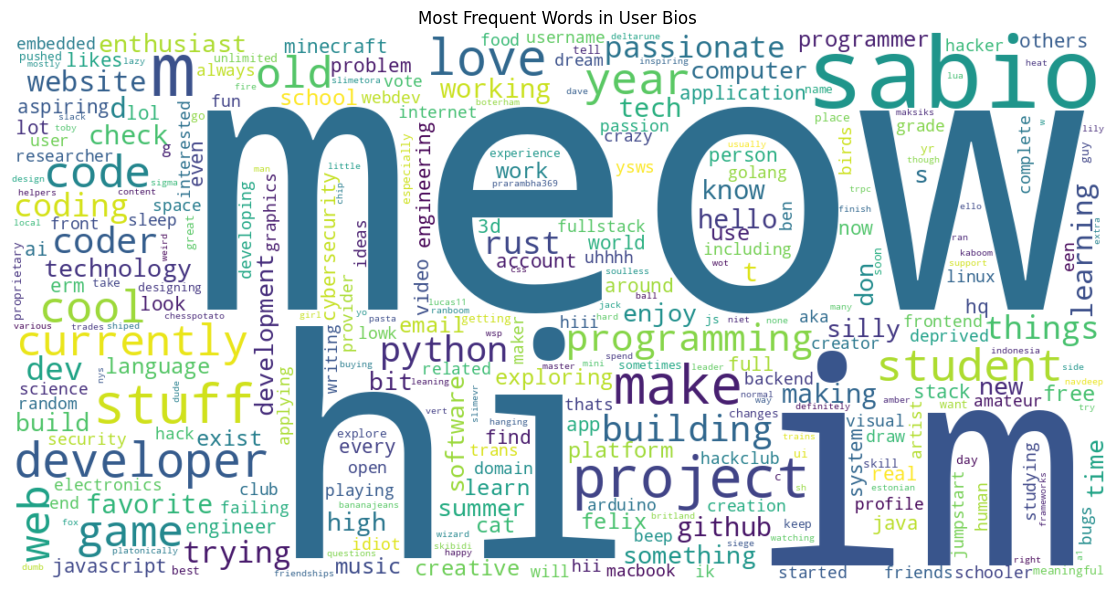

In [83]:
bio_texts = df['bio'].fillna('').astype(str)
bio_texts = bio_texts[bio_texts.str.strip() != '']  # Remove empty bios

if len(bio_texts) > 0:
    corpus = ' '.join(bio_texts.tolist())
    corpus = re.sub(r"https?://\S+", " ", corpus)  # Remove URLs
    corpus = re.sub(r"[^A-Za-z0-9_+#-]+", " ", corpus)  # Keep only alphanumeric and some symbols
    corpus = re.sub(r"\s+", " ", corpus).strip().lower()  # Clean whitespace and lowercase

    if corpus:
        wc = WordCloud(
            width=1200, height=600, background_color='white',
            collocations=False, max_words=300
        ).generate(corpus)

        fig = plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Most Frequent Words in User Bios')
        plt.tight_layout()

        save_matplotlib_current(name='user_bio_word_cloud', description='Word cloud of most frequent words in user bios', friendly_name='User Bio Word Cloud')
        plt.show()
    else:
        print('Bio text is empty after cleaning.')
else:
    print('No bio text found or all bios are empty.')

# User activity metrics

Analysis of various user activity metrics

In [84]:
_df = df.copy()

metrics = ['projects_count', 'devlogs_count', 'votes_count', 'ships_count']
for col in metrics:
    _df[f'{col}_num'] = pd.to_numeric(_df[col], errors='coerce')

corr_data = _df[[f'{col}_num' for col in metrics]].rename(columns={
    'projects_count_num': 'Projects',
    'devlogs_count_num': 'Devlogs', 
    'votes_count_num': 'Votes',
    'ships_count_num': 'Ships'
}).corr()

fig = px.imshow(
    corr_data,
    labels=dict(color='Correlation'),
    color_continuous_scale='RdBu_r',
    aspect='auto',
    title='User Activity Metrics Correlation'
)

for i in range(len(corr_data.columns)):
    for j in range(len(corr_data.columns)):
        fig.add_annotation(
            x=i, y=j,
            text=f'{corr_data.iloc[j, i]:.2f}',
            showarrow=False,
            font=dict(color='black' if abs(corr_data.iloc[j, i]) < 0.5 else 'white')
        )

fig.update_layout(height=max(DEFAULT_HEIGHT, 450))
fig.show()

save_plotly(fig, name='user_activity_correlation', description='Correlation matrix of user activity metrics', friendly_name='User Activity Correlation')

# Save all the info to a index for web stuff

In [68]:
index_path = EXPORT_DIR / 'index.json'
with open(index_path, 'w', encoding='utf-8') as f:
    json.dump(index, f, indent=4)
print(f'Wrote index to {index_path}')

Wrote index to /home/ajayanto/projects/SoM-Analytics/data/processed/users/index.json
